In [314]:
#research

import pandas as pd

businesses = pd.read_csv("../data/raw/businesses.csv")
reviews = pd.read_csv("../data/raw/reviews.csv")

print("Businesses:", businesses.shape)
print("Reviews:", reviews.shape)

businesses.head()

reviews.info()
reviews.describe()
reviews.isnull().sum()

Businesses: (12, 10)
Reviews: (2100, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   review_id          2100 non-null   str  
 1   company_id         2100 non-null   str  
 2   company_name       2100 non-null   str  
 3   city               2100 non-null   str  
 4   rating             2100 non-null   int64
 5   review_date        2100 non-null   str  
 6   review_text        2100 non-null   str  
 7   overall_sentiment  2100 non-null   str  
 8   primary_aspect     2100 non-null   str  
 9   aspect_labels      2100 non-null   str  
 10  mentioned_driver   54 non-null     str  
 11  is_anomaly         2100 non-null   int64
 12  anomaly_reason     2100 non-null   str  
 13  source_type        2100 non-null   str  
dtypes: int64(2), str(12)
memory usage: 229.8 KB


review_id               0
company_id              0
company_name            0
city                    0
rating                  0
review_date             0
review_text             0
overall_sentiment       0
primary_aspect          0
aspect_labels           0
mentioned_driver     2046
is_anomaly              0
anomaly_reason          0
source_type             0
dtype: int64

In [315]:
reviews["rating"].value_counts().sort_index()
reviews["overall_sentiment"].value_counts()
reviews["primary_aspect"].value_counts()
reviews["is_anomaly"].value_counts()

is_anomaly
0    1954
1     146
Name: count, dtype: int64

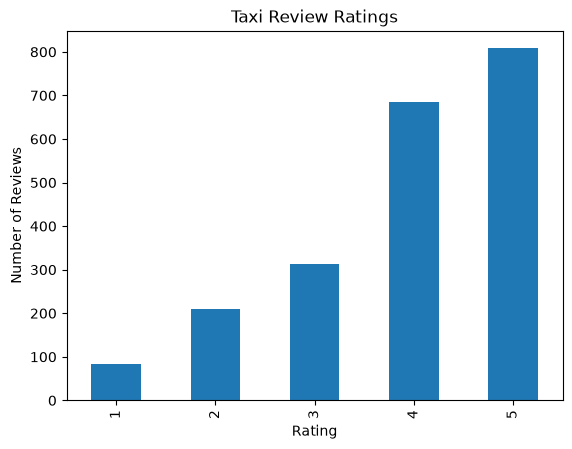

In [316]:
#visualize

import matplotlib.pyplot as plt

reviews["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Taxi Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

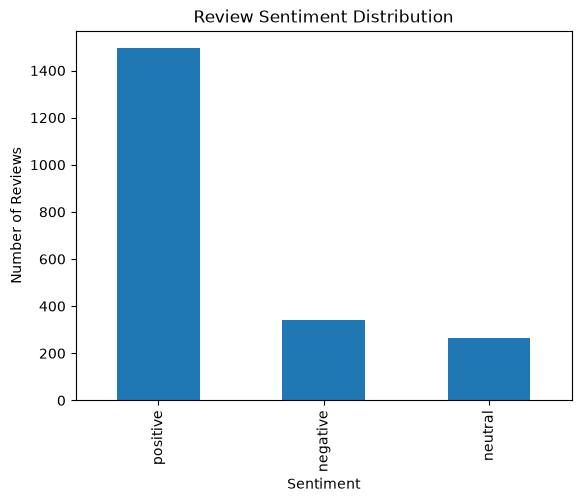

In [317]:
reviews["overall_sentiment"].value_counts().plot(kind="bar")

plt.title("Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

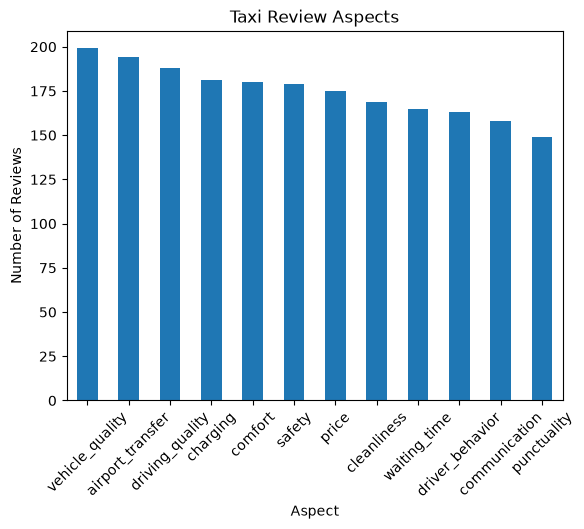

In [318]:
reviews["primary_aspect"].value_counts().plot(kind="bar")

plt.title("Taxi Review Aspects")
plt.xlabel("Aspect")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

In [319]:
#text inspection

for review in reviews["review_text"].head(10):
    print(review)
    print()

The taxi arrived around the expected time.

The ride was smooth. The driver arrived exactly on time. The car felt new and well maintained.

The seats were comfortable and the ride smooth. The vehicle was very clean inside.

The airport transfer went normally. The fare was expensive for a short trip.

The car was spotless and fresh.

It was a very comfortable trip. I felt comfortable with the driver's driving.

The ride was not smooth. The car was not very clean.

There were several sudden lane changes.

The driver communicated professionally. The interior was clean and well maintained.

The airport pickup went smoothly.



In [320]:
print("===== RATINGS =====")
print(reviews["rating"].value_counts().sort_index())

print("\n===== SENTIMENT =====")
print(reviews["overall_sentiment"].value_counts())

print("\n===== ASPECTS =====")
print(reviews["primary_aspect"].value_counts())

print("\n===== ANOMALIES =====")
print(reviews["is_anomaly"].value_counts())

===== RATINGS =====
rating
1     83
2    209
3    314
4    686
5    808
Name: count, dtype: int64

===== SENTIMENT =====
overall_sentiment
positive    1494
negative     342
neutral      264
Name: count, dtype: int64

===== ASPECTS =====
primary_aspect
vehicle_quality     199
airport_transfer    194
driving_quality     188
charging            181
comfort             180
safety              179
price               175
cleanliness         169
waiting_time        165
driver_behavior     163
communication       158
punctuality         149
Name: count, dtype: int64

===== ANOMALIES =====
is_anomaly
0    1954
1     146
Name: count, dtype: int64


In [321]:
company_counts = (
    reviews["company_name"]
    .value_counts()
    .sort_values(ascending=False)
)

print(company_counts)

company_name
ETaxi Tirana          317
VoltRide Albania      222
GreenRide Albania     216
EcoCab Albania        199
Urban EV Taxi         191
Ion Taxi Albania      175
BlueVolt Taxi         165
Drita Electric        144
E-Move Taxi           131
ChargeCab             126
Spark Taxi            114
Alba Electric Ride    100
Name: count, dtype: int64


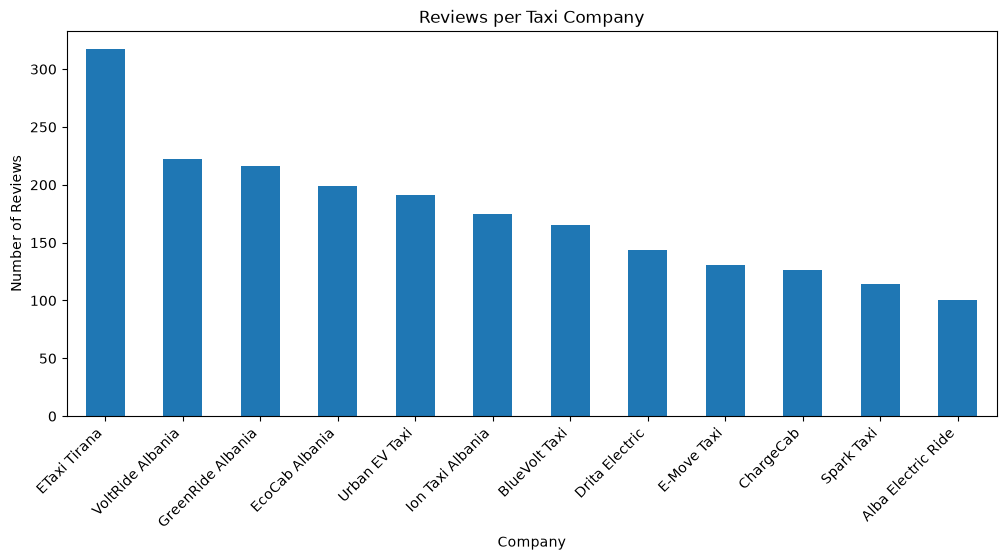

In [322]:
company_counts.plot(kind="bar", figsize=(12, 5))

plt.title("Reviews per Taxi Company")
plt.xlabel("Company")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.show()

In [323]:
reviews["text_length"] = reviews["review_text"].str.len()

print(reviews["text_length"].describe())

count    2100.000000
mean       65.108095
std        27.865245
min        17.000000
25%        43.000000
50%        64.000000
75%        82.000000
max       145.000000
Name: text_length, dtype: float64


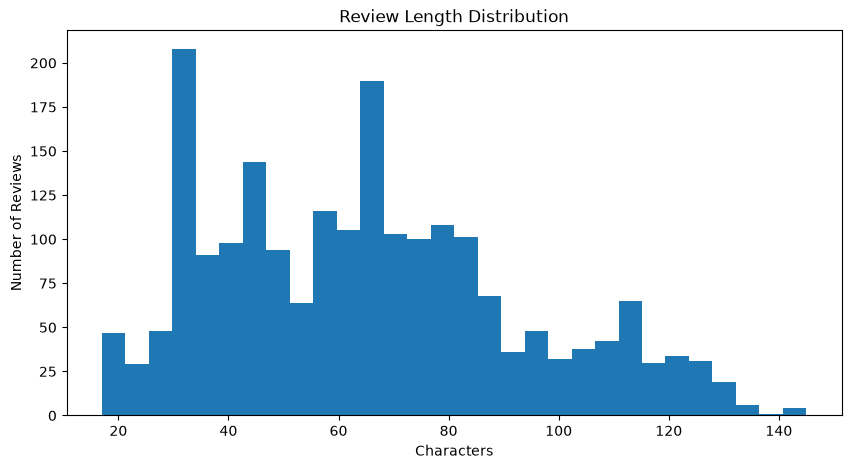

In [324]:
reviews["text_length"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5)
)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Number of Reviews")
plt.show()

In [325]:
reviews["review_date"] = pd.to_datetime(reviews["review_date"])

print(
    reviews["review_date"].min(),
    reviews["review_date"].max()
)

2025-01-01 01:00:00 2026-08-28 11:00:00


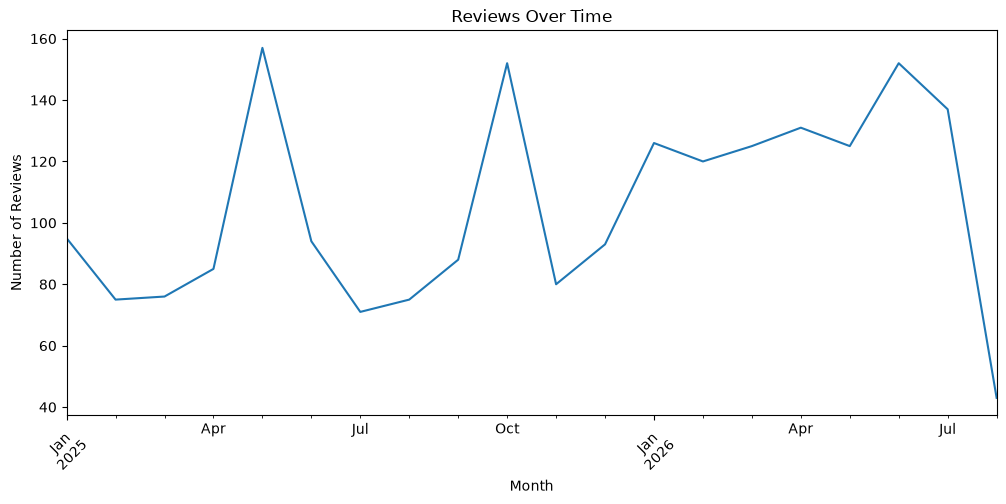

In [326]:
reviews["review_date"].dt.to_period("M").value_counts().sort_index().plot(
    figsize=(12, 5)
)

plt.title("Reviews Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

In [327]:
reviews[["rating", "overall_sentiment", "primary_aspect", "review_text"]].head(20)

,rating,overall_sentiment,primary_aspect,review_text
0,3,neutral,punctuality,The taxi arrived around the expected time.
1,5,positive,driving_quality,The ride was smooth. The driver arrived exactl...
2,5,positive,comfort,The seats were comfortable and the ride smooth...
3,5,positive,airport_transfer,The airport transfer went normally. The fare w...
4,4,positive,cleanliness,The car was spotless and fresh.
5,4,positive,comfort,It was a very comfortable trip. I felt comfort...
6,2,negative,driving_quality,The ride was not smooth. The car was not very ...
7,5,positive,safety,There were several sudden lane changes.
8,4,positive,driver_behavior,The driver communicated professionally. The in...
9,4,positive,airport_transfer,The airport pickup went smoothly.


In [328]:
print(reviews.shape)

print(reviews.isnull().sum())
print(reviews.duplicated().sum())
print(reviews["rating"].value_counts().sort_index())
print(reviews["overall_sentiment"].value_counts())
print(reviews["primary_aspect"].value_counts())
print(reviews["is_anomaly"].value_counts())

(2100, 15)
review_id               0
company_id              0
company_name            0
city                    0
rating                  0
review_date             0
review_text             0
overall_sentiment       0
primary_aspect          0
aspect_labels           0
mentioned_driver     2046
is_anomaly              0
anomaly_reason          0
source_type             0
text_length             0
dtype: int64
0
rating
1     83
2    209
3    314
4    686
5    808
Name: count, dtype: int64
overall_sentiment
positive    1494
negative     342
neutral      264
Name: count, dtype: int64
primary_aspect
vehicle_quality     199
airport_transfer    194
driving_quality     188
charging            181
comfort             180
safety              179
price               175
cleanliness         169
waiting_time        165
driver_behavior     163
communication       158
punctuality         149
Name: count, dtype: int64
is_anomaly
0    1954
1     146
Name: count, dtype: int64


In [329]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/reviews.csv")

# Keep only what we need for this model
sentiment_df = df[["review_text", "overall_sentiment"]].copy()

# Check
print(sentiment_df.head())
print()
print(sentiment_df.shape)
print()
print(sentiment_df["overall_sentiment"].value_counts())

                                         review_text overall_sentiment
0         The taxi arrived around the expected time.           neutral
1  The ride was smooth. The driver arrived exactl...          positive
2  The seats were comfortable and the ride smooth...          positive
3  The airport transfer went normally. The fare w...          positive
4                    The car was spotless and fresh.          positive

(2100, 2)

overall_sentiment
positive    1494
negative     342
neutral      264
Name: count, dtype: int64


In [330]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Separate X, y
X = sentiment_df["review_text"]
y = sentiment_df["overall_sentiment"]

# 2. First split: 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 3. Second split: Break the 30% Temp into 15% Val and 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,   # Fixed: split from temp data
    test_size=0.50,   # 50% of 30% is 15% each
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# 4. Model pipeline
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
      
    ))
])

# 5. Train
model.fit(X_train, y_train)

# 6. Validation Evaluation
y_val_pred = model.predict(X_val)
print("\n==============================")
print("VALIDATION RESULTS")
print("==============================")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred))

# 7. Test Evaluation
y_test_pred = model.predict(X_test)
print("\n==============================")
print("TEST RESULTS")
print("==============================")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))


Train size: 1470 (70.0%)
Validation size: 315 (15.0%)
Test size: 315 (15.0%)

VALIDATION RESULTS
Accuracy: 0.9015873015873016

Classification Report:
               precision    recall  f1-score   support

    negative       0.98      0.84      0.91        51
     neutral       0.71      0.68      0.69        40
    positive       0.92      0.96      0.94       224

    accuracy                           0.90       315
   macro avg       0.87      0.82      0.84       315
weighted avg       0.90      0.90      0.90       315


Confusion Matrix:
 [[ 43   2   6]
 [  0  27  13]
 [  1   9 214]]

TEST RESULTS
Accuracy: 0.9079365079365079

Classification Report:
               precision    recall  f1-score   support

    negative       0.94      0.88      0.91        52
     neutral       0.80      0.62      0.70        39
    positive       0.92      0.96      0.94       224

    accuracy                           0.91       315
   macro avg       0.88      0.82      0.85       315
weighted

In [331]:
# ==========================================
# TF-IDF + Logistic Regression Tuning
# ==========================================

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


# ==========================================
# 1. Create pipeline
# ==========================================

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english"
    )),
    
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])


# ==========================================
# 2. Define parameters to test
# ==========================================

param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],
    
    "tfidf__min_df": [
        1,
        2,
        3
    ],
    
    "tfidf__sublinear_tf": [
        True,
        False
    ],
    
    "classifier__C": [
        0.1,
        1,
        10
    ]
}


# ==========================================
# 3. Grid Search
# ==========================================

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)


# ==========================================
# 4. Train
# ==========================================

grid_search.fit(X_train, y_train)


# ==========================================
# 5. Best parameters
# ==========================================

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters:
{'classifier__C': 10, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}

Best Cross-Validation Macro F1:
0.8811412833070706


In [332]:
# ==========================================
# 6. Validation evaluation
# ==========================================

sentiment_model = grid_search.best_estimator_

y_val_pred = sentiment_model.predict(X_val)

print("\n==============================")
print("TUNED VALIDATION RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


TUNED VALIDATION RESULTS
Accuracy: 0.9111111111111111

Classification Report:
              precision    recall  f1-score   support

    negative       0.96      0.86      0.91        51
     neutral       0.72      0.78      0.75        40
    positive       0.94      0.95      0.94       224

    accuracy                           0.91       315
   macro avg       0.87      0.86      0.87       315
weighted avg       0.91      0.91      0.91       315


Confusion Matrix:
[[ 44   2   5]
 [  0  31   9]
 [  2  10 212]]


In [333]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 10, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}

Best Cross-Validation Macro F1:
0.8811412833070706


In [334]:
# ==========================================
# FINAL TEST EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predict on completely untouched test data
y_test_pred = sentiment_model.predict(X_test)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


FINAL TEST RESULTS
Accuracy: 0.9111111111111111

Classification Report:
              precision    recall  f1-score   support

    negative       0.94      0.90      0.92        52
     neutral       0.70      0.79      0.75        39
    positive       0.95      0.93      0.94       224

    accuracy                           0.91       315
   macro avg       0.86      0.88      0.87       315
weighted avg       0.91      0.91      0.91       315


Confusion Matrix:
[[ 47   0   5]
 [  1  31   7]
 [  2  13 209]]


In [335]:
#save sentiment
import joblib

joblib.dump(
    sentiment_model,
    "../models/sentiment_model.pkl"
)

print("Sentiment model saved!")

Sentiment model saved!


In [336]:
#Aspect model

#load data

import pandas as pd 

df=pd.read_csv("../data/raw/reviews.csv")

aspect_df=df[["review_text", "primary_aspect"]].copy()


aspect_df=aspect_df.dropna()

#split data


X=aspect_df["review_text"]
y=aspect_df["primary_aspect"]

print("Dataset shape:", aspect_df.shape)

print("\nAspect distribution:")
print(y.value_counts())


Dataset shape: (2100, 2)

Aspect distribution:
primary_aspect
vehicle_quality     199
airport_transfer    194
driving_quality     188
charging            181
comfort             180
safety              179
price               175
cleanliness         169
waiting_time        165
driver_behavior     163
communication       158
punctuality         149
Name: count, dtype: int64


In [337]:
#train/test split

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import  train_test_split


X_train,X_temp,y_train,y_temp=train_test_split(

  X,y,
  test_size=0.30,
  random_state=42,
  stratify=y
)

X_val,X_test,y_val,y_test=train_test_split(
  X_temp,y_temp,
  test_size=0.50,
  random_state=42,
  stratify=y_temp
)



print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train size: 1470 (70.0%)
Validation size: 315 (15.0%)
Test size: 315 (15.0%)


In [338]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

#pipeline

model=Pipeline([
   ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2)
    )),
    
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

#train


model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](12,)","['airport_transfer','charging','cleanliness',...,'safety', 'vehicle_quality','waiting_time']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By defa

In [339]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# Validation
# ==========================================

y_val_pred = model.predict(X_val)

print("\n==============================")
print("VALIDATION RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


VALIDATION RESULTS
Accuracy: 0.7746031746031746

Classification Report:
                  precision    recall  f1-score   support

airport_transfer       0.74      0.90      0.81        29
        charging       0.80      0.74      0.77        27
     cleanliness       0.80      0.80      0.80        25
         comfort       0.79      0.85      0.82        27
   communication       0.80      0.67      0.73        24
 driver_behavior       0.83      0.79      0.81        24
 driving_quality       0.88      0.79      0.83        28
           price       0.69      0.74      0.71        27
     punctuality       0.77      0.77      0.77        22
          safety       0.72      0.67      0.69        27
 vehicle_quality       0.72      0.87      0.79        30
    waiting_time       0.81      0.68      0.74        25

        accuracy                           0.77       315
       macro avg       0.78      0.77      0.77       315
    weighted avg       0.78      0.77      0.77       3

In [340]:
# ==========================================
# ASPECT CLASSIFICATION - TUNING
# ==========================================

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


# ==========================================
# 1. Pipeline
# ==========================================

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english"
    )),
    
    ("classifier", LogisticRegression(
        max_iter=2000
    ))
])


# ==========================================
# 2. Parameters
# ==========================================

param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],
    
    "tfidf__min_df": [
        1,
        2,
        3
    ],
    
    "tfidf__sublinear_tf": [
        True,
        False
    ],
    
    "classifier__C": [
        0.1,
        1,
        10
    ]
}


# ==========================================
# 3. GridSearchCV
# ==========================================

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)


# ==========================================
# 4. Train
# ==========================================

grid_search.fit(X_train, y_train)


# ==========================================
# 5. Best parameters
# ==========================================

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters:
{'classifier__C': 10, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}

Best Cross-Validation Macro F1:
0.7392852203727099


In [341]:
# ==========================================
# VALIDATION - TUNED MODEL
# ==========================================

aspect_model = grid_search.best_estimator_

y_val_pred = aspect_model.predict(X_val)

print("\n==============================")
print("TUNED VALIDATION RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


TUNED VALIDATION RESULTS
Accuracy: 0.8158730158730159

Classification Report:
                  precision    recall  f1-score   support

airport_transfer       0.84      0.90      0.87        29
        charging       0.85      0.85      0.85        27
     cleanliness       0.82      0.72      0.77        25
         comfort       0.85      0.85      0.85        27
   communication       0.80      0.67      0.73        24
 driver_behavior       0.84      0.88      0.86        24
 driving_quality       0.85      0.82      0.84        28
           price       0.84      0.78      0.81        27
     punctuality       0.78      0.82      0.80        22
          safety       0.75      0.67      0.71        27
 vehicle_quality       0.78      0.93      0.85        30
    waiting_time       0.79      0.88      0.83        25

        accuracy                           0.82       315
       macro avg       0.82      0.81      0.81       315
    weighted avg       0.82      0.82      0.81  

In [342]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 10, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False}

Best Cross-Validation Macro F1:
0.7392852203727099


In [343]:
# ==========================================
# FINAL TEST EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

aspect_model = grid_search.best_estimator_

y_test_pred = aspect_model.predict(X_test)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


FINAL TEST RESULTS
Accuracy: 0.7746031746031746

Classification Report:
                  precision    recall  f1-score   support

airport_transfer       0.81      0.86      0.83        29
        charging       0.83      0.89      0.86        27
     cleanliness       0.69      0.77      0.73        26
         comfort       0.81      0.63      0.71        27
   communication       0.80      0.70      0.74        23
 driver_behavior       0.82      0.72      0.77        25
 driving_quality       0.86      0.86      0.86        28
           price       0.77      0.65      0.71        26
     punctuality       0.67      0.87      0.75        23
          safety       0.78      0.78      0.78        27
 vehicle_quality       0.81      0.87      0.84        30
    waiting_time       0.67      0.67      0.67        24

        accuracy                           0.77       315
       macro avg       0.78      0.77      0.77       315
    weighted avg       0.78      0.77      0.77       3

In [344]:
joblib.dump(
    aspect_model,
    "../models/aspect_model.pkl"
)

print("Aspect model saved!")

Aspect model saved!


In [359]:
# ==========================================
# ANOMALY DETECTION - DATA INSPECTION
# ==========================================

print("Anomaly distribution:")
print(df["is_anomaly"].value_counts())

print("\nAnomaly percentages:")
print(df["is_anomaly"].value_counts(normalize=True) * 100)

print("\nAnomaly reasons:")
print(df["anomaly_reason"].value_counts())

print("\nAnomaly reasons for anomalies only:")
print(
    df.loc[df["is_anomaly"] == 1, "anomaly_reason"]
      .value_counts()
)

print("\nRating by anomaly:")
print(
    pd.crosstab(
        df["rating"],
        df["is_anomaly"],
        normalize="columns"
    ).round(3)
)

print("\nSentiment by anomaly:")
print(
    pd.crosstab(
        df["overall_sentiment"],
        df["is_anomaly"],
        normalize="columns"
    ).round(3)
)

print("\nAspect by anomaly:")
print(
    pd.crosstab(
        df["primary_aspect"],
        df["is_anomaly"],
        normalize="columns"
    ).round(3)
)

print("\n==============================")
print("NORMAL EXAMPLES")
print("==============================")

print(
    df.loc[
        df["is_anomaly"] == 0,
        ["review_text", "rating", "overall_sentiment",
         "primary_aspect", "anomaly_reason"]
    ].sample(10, random_state=42).to_string(index=False)
)


print("\n==============================")
print("ANOMALY EXAMPLES")
print("==============================")

print(
    df.loc[
        df["is_anomaly"] == 1,
        ["review_text", "rating", "overall_sentiment",
         "primary_aspect", "anomaly_reason"]
    ].sample(10, random_state=42).to_string(index=False)
)

Anomaly distribution:
is_anomaly
0    1954
1     146
Name: count, dtype: int64

Anomaly percentages:
is_anomaly
0    93.047619
1     6.952381
Name: proportion, dtype: float64

Anomaly reasons:
anomaly_reason
none                   1954
duplicate_like_text      47
review_burst             36
new_account_pattern      35
rating_burst             28
Name: count, dtype: int64

Anomaly reasons for anomalies only:
anomaly_reason
duplicate_like_text    47
review_burst           36
new_account_pattern    35
rating_burst           28
Name: count, dtype: int64

Rating by anomaly:
is_anomaly      0      1
rating                  
1           0.039  0.048
2           0.098  0.123
3           0.147  0.185
4           0.329  0.295
5           0.387  0.349

Sentiment by anomaly:
is_anomaly             0      1
overall_sentiment              
negative           0.160  0.205
neutral            0.124  0.151
positive           0.716  0.644

Aspect by anomaly:
is_anomaly            0      1
primary_aspect 

In [360]:
# ==========================================
# ANOMALY DETECTION - TEMPORAL INSPECTION
# ==========================================

df["review_date"] = pd.to_datetime(df["review_date"])

print("Date range:")
print("Start:", df["review_date"].min())
print("End:", df["review_date"].max())


print("\nReviews per day:")
print(
    df.groupby(df["review_date"].dt.date)
      .size()
      .describe()
)


print("\nReviews per day for anomalies:")
print(
    df[df["is_anomaly"] == 1]
      .groupby(df["review_date"].dt.date)
      .size()
      .sort_values(ascending=False)
      .head(20)
)
daily_stats = (
    df.groupby(df["review_date"].dt.date)
      .agg(
          total_reviews=("is_anomaly", "size"),
          anomalies=("is_anomaly", "sum")
      )
)

daily_stats["anomaly_rate"] = (
    daily_stats["anomalies"] /
    daily_stats["total_reviews"]
)

print("\nDays with highest anomaly rates:")
print(
    daily_stats
    .sort_values("anomaly_rate", ascending=False)
    .head(20)
)

Date range:
Start: 2025-01-01 01:00:00
End: 2026-08-28 11:00:00

Reviews per day:
count    579.000000
mean       3.626943
std        2.685157
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       29.000000
dtype: float64

Reviews per day for anomalies:
review_date
2025-10-30    25
2025-05-01    23
2025-05-02    18
2025-10-28    18
2025-05-03    17
2025-10-29    16
2026-07-23     2
2026-01-20     1
2026-02-01     1
2026-01-28     1
2026-02-21     1
2026-02-25     1
2026-03-12     1
2026-03-16     1
2026-03-17     1
2026-03-22     1
2026-03-25     1
2026-02-15     1
2026-04-17     1
2026-05-08     1
dtype: int64

Days with highest anomaly rates:
             total_reviews  anomalies  anomaly_rate
review_date                                        
2026-08-25               1          1      1.000000
2025-05-01              24         23      0.958333
2025-10-28              19         18      0.947368
2025-10-30              29         25      0.862069


In [361]:
print("Number of companies:")
print(df["company_id"].nunique())

print("\nReviews per company:")
print(
    df["company_id"]
      .value_counts()
      .describe()
)

print("\nTop companies by review count:")
print(
    df["company_id"]
      .value_counts()
      .head(20)
)
print("\nCompanies involved in anomalies:")

print(
    df.loc[df["is_anomaly"] == 1, "company_id"]
      .value_counts()
      .head(20)
)
burst_dates = [
    "2025-05-01",
    "2025-05-02",
    "2025-05-03",
    "2025-10-28",
    "2025-10-29",
    "2025-10-30"
]

burst_df = df[
    df["review_date"].dt.strftime("%Y-%m-%d").isin(burst_dates)
]

print("\nReviews during major burst dates:")
print(
    burst_df.groupby(
        ["review_date", "company_id"]
    ).size().sort_values(ascending=False).head(30)
)

Number of companies:
12

Reviews per company:
count     12.000000
mean     175.000000
std       60.022723
min      100.000000
25%      129.750000
50%      170.000000
75%      203.250000
max      317.000000
Name: count, dtype: float64

Top companies by review count:
company_id
C001    317
C002    222
C007    216
C004    199
C003    191
C010    175
C006    165
C005    144
C008    131
C009    126
C011    114
C012    100
Name: count, dtype: int64

Companies involved in anomalies:
company_id
C001    19
C002    19
C003    18
C006    14
C007    13
C004    12
C010    11
C005    10
C009    10
C008     8
C011     7
C012     5
Name: count, dtype: int64

Reviews during major burst dates:
review_date          company_id
2025-05-03 23:00:00  C003          2
2025-05-01 20:00:00  C006          2
2025-10-30 05:00:00  C002          2
                     C005          2
2025-05-01 04:00:00  C002          1
2025-05-01 02:00:00  C010          1
2025-05-01 10:00:00  C001          1
                     C00

In [362]:
# ==========================================
# NORMAL VS ANOMALY FEATURES
# ==========================================

# Create text_length if missing
if "text_length" not in df.columns:
    df["text_length"] = (
        df["review_text"]
        .fillna("")
        .astype(str)
        .str.len()
    )

print("NORMAL VS ANOMALY FEATURES")
print("==============================")

# Features we want to analyze
features = [
    "reviews_same_day",
    "company_reviews_same_day",
    "text_length"
]

# Keep only features that actually exist
available_features = [
    feature for feature in features
    if feature in df.columns
]

# Check that is_anomaly exists
if "is_anomaly" not in df.columns:
    print("ERROR: 'is_anomaly' column is missing.")
else:
    print(
        df.groupby("is_anomaly")[available_features]
        .mean()
    )

NORMAL VS ANOMALY FEATURES
            reviews_same_day  company_reviews_same_day  text_length
is_anomaly                                                         
0                   4.592119                  1.323951    65.067042
1                  19.253425                  2.650685    65.657534


In [363]:
# ==========================================
# NORMAL VS ANOMALY - DETAILED FEATURES
# ==========================================

# Create text_length if it doesn't exist
if "text_length" not in df.columns:
    df["text_length"] = (
        df["review_text"]
        .fillna("")
        .astype(str)
        .str.len()
    )

print("NORMAL VS ANOMALY FEATURES")
print("==============================")

features = [
    "reviews_same_day",
    "company_reviews_same_day",
    "rating_reviews_same_day",
    "text_length"
]

# Only use columns that exist
available_features = [
    col for col in features
    if col in df.columns
]

# Show which features are available
print("Features used:", available_features)
print()

print(
    df.groupby("is_anomaly")[available_features]
    .agg(["mean", "median", "max"])
    .round(2)
)

NORMAL VS ANOMALY FEATURES
Features used: ['reviews_same_day', 'company_reviews_same_day', 'rating_reviews_same_day', 'text_length']

           reviews_same_day            company_reviews_same_day             \
                       mean median max                     mean median max   
is_anomaly                                                                   
0                      4.59    4.0  29                     1.32    1.0   6   
1                     19.25   20.0  29                     2.65    2.0   6   

           rating_reviews_same_day            text_length              
                              mean median max        mean median  max  
is_anomaly                                                             
0                             1.11    1.0   5       65.07   64.0  145  
1                             1.62    1.0   5       65.66   64.0  128  


In [364]:
# ==========================================
# ANOMALIES OVER TIME
# ==========================================

df["year_month"] = df["review_date"].dt.to_period("M")

monthly_anomalies = (
    df.groupby("year_month")
      .agg(
          total_reviews=("is_anomaly", "size"),
          anomalies=("is_anomaly", "sum")
      )
)

monthly_anomalies["anomaly_rate"] = (
    monthly_anomalies["anomalies"] /
    monthly_anomalies["total_reviews"]
)

print(monthly_anomalies)

            total_reviews  anomalies  anomaly_rate
year_month                                        
2025-01                95          0      0.000000
2025-02                75          0      0.000000
2025-03                76          0      0.000000
2025-04                85          0      0.000000
2025-05               157         58      0.369427
2025-06                94          0      0.000000
2025-07                71          0      0.000000
2025-08                75          0      0.000000
2025-09                88          0      0.000000
2025-10               152         59      0.388158
2025-11                80          0      0.000000
2025-12                93          0      0.000000
2026-01               126          2      0.015873
2026-02               120          4      0.033333
2026-03               125          5      0.040000
2026-04               131          1      0.007634
2026-05               125          3      0.024000
2026-06               152      

In [365]:
# ==========================================
# ANOMALY FEATURE ENGINEERING
# ==========================================

# Make sure review_date is datetime
df["review_date"] = pd.to_datetime(df["review_date"])

# Create a day-level column
df["review_day"] = df["review_date"].dt.date

# ------------------------------------------
# 1. Total reviews submitted on the same day
# ------------------------------------------

df["reviews_same_day"] = (
    df.groupby("review_day")["review_id"]
    .transform("count")
)

# ------------------------------------------
# 2. Reviews from the same company on that day
# ------------------------------------------

df["company_reviews_same_day"] = (
    df.groupby(["company_id", "review_day"])["review_id"]
    .transform("count")
)

# ------------------------------------------
# 3. Reviews with the same rating
#    for the same company on the same day
# ------------------------------------------

df["rating_reviews_same_day"] = (
    df.groupby(
        ["company_id", "review_day", "rating"]
    )["review_id"]
    .transform("count")
)

# ------------------------------------------
# Check features
# ------------------------------------------

print("ANOMALY FEATURES CREATED")
print("==============================")

print(
    df[
        [
            "reviews_same_day",
            "company_reviews_same_day",
            "rating_reviews_same_day"
        ]
    ].head()
)

print("\nFeature statistics:")
print(
    df[
        [
            "reviews_same_day",
            "company_reviews_same_day",
            "rating_reviews_same_day"
        ]
    ].describe()
)

ANOMALY FEATURES CREATED
   reviews_same_day  company_reviews_same_day  rating_reviews_same_day
0                 5                         1                        1
1                 8                         1                        1
2                 5                         1                        1
3                 6                         1                        1
4                 6                         1                        1

Feature statistics:
       reviews_same_day  company_reviews_same_day  rating_reviews_same_day
count       2100.000000                2100.00000              2100.000000
mean           5.611429                   1.41619                 1.146667
std            4.972862                   0.77116                 0.427066
min            1.000000                   1.00000                 1.000000
25%            3.000000                   1.00000                 1.000000
50%            4.000000                   1.00000                 1.000000
75%

In [366]:
# ==========================================
# ANOMALY FEATURE ENGINEERING
# ==========================================

import pandas as pd

# Make sure review_date is datetime
df["review_date"] = pd.to_datetime(df["review_date"])

# Create day-level feature
df["review_day"] = df["review_date"].dt.date

# 1. Total reviews on the same day
df["reviews_same_day"] = (
    df.groupby("review_day")["review_id"]
    .transform("count")
)

# 2. Reviews from the same company on the same day
df["company_reviews_same_day"] = (
    df.groupby(["company_id", "review_day"])["review_id"]
    .transform("count")
)

# 3. Reviews with the same rating for the same company on the same day
df["rating_reviews_same_day"] = (
    df.groupby(
        ["company_id", "review_day", "rating"]
    )["review_id"]
    .transform("count")
)

# Make sure text_length exists
if "text_length" not in df.columns:
    df["text_length"] = (
        df["review_text"]
        .fillna("")
        .astype(str)
        .str.len()
    )

print("ANOMALY FEATURES CREATED")
print("==============================")

print(
    df[
        [
            "reviews_same_day",
            "company_reviews_same_day",
            "rating_reviews_same_day",
            "rating",
            "text_length"
        ]
    ].head()
)

print("\nFeature statistics:")
print(
    df[
        [
            "reviews_same_day",
            "company_reviews_same_day",
            "rating_reviews_same_day",
            "rating",
            "text_length"
        ]
    ].describe()
)

ANOMALY FEATURES CREATED
   reviews_same_day  company_reviews_same_day  rating_reviews_same_day  \
0                 5                         1                        1   
1                 8                         1                        1   
2                 5                         1                        1   
3                 6                         1                        1   
4                 6                         1                        1   

   rating  text_length  
0       3           42  
1       5           94  
2       5           82  
3       5           76  
4       4           31  

Feature statistics:
       reviews_same_day  company_reviews_same_day  rating_reviews_same_day  \
count       2100.000000                2100.00000              2100.000000   
mean           5.611429                   1.41619                 1.146667   
std            4.972862                   0.77116                 0.427066   
min            1.000000                   1.000

In [367]:
print([
    "reviews_same_day",
    "company_reviews_same_day",
    "rating_reviews_same_day",
    "rating",
    "text_length"
])

print("\nActually in dataframe:")
print([
    col for col in [
        "reviews_same_day",
        "company_reviews_same_day",
        "rating_reviews_same_day",
        "rating",
        "text_length"
    ]
    if col in df.columns
])

['reviews_same_day', 'company_reviews_same_day', 'rating_reviews_same_day', 'rating', 'text_length']

Actually in dataframe:
['reviews_same_day', 'company_reviews_same_day', 'rating_reviews_same_day', 'rating', 'text_length']


In [368]:
# ==========================================
# ANOMALY CLASSIFIER - TRAIN / VAL / TEST
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

# ==========================================
# MAKE SURE REQUIRED FEATURES EXIST
# ==========================================

# Create text_length if missing
if "text_length" not in df.columns:
    df["text_length"] = (
        df["review_text"]
        .fillna("")
        .astype(str)
        .str.len()
    )

# Features we want to use
features = [
    "reviews_same_day",
    "company_reviews_same_day",
    "rating_reviews_same_day",
    "rating",
    "text_length"
]

# Check which features actually exist
missing_features = [
    feature for feature in features
    if feature not in df.columns
]

if missing_features:
    print("MISSING FEATURES:")
    print(missing_features)
    print("\nAvailable columns:")
    print(df.columns.tolist())
    raise KeyError(
        f"These features are missing from df: {missing_features}"
    )

# ==========================================
# FEATURES / TARGET
# ==========================================

X = df[features]
y = df["is_anomaly"]

print("Features used:")
print(features)

print("\nDataset shape:", X.shape)
print("Anomaly distribution:")
print(y.value_counts())

# ==========================================
# TRAIN / VALIDATION / TEST SPLIT
# ==========================================

# 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"\nTrain size: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation size: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

# ==========================================
# MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ==========================================
# VALIDATION
# ==========================================

y_val_pred = model.predict(X_val)

print("\n==============================")
print("VALIDATION RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print(
    "Balanced Accuracy:",
    balanced_accuracy_score(y_val, y_val_pred)
)

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Features used:
['reviews_same_day', 'company_reviews_same_day', 'rating_reviews_same_day', 'rating', 'text_length']

Dataset shape: (2100, 5)
Anomaly distribution:
is_anomaly
0    1954
1     146
Name: count, dtype: int64



Train size: 1470 (70.0%)
Validation size: 315 (15.0%)
Test size: 315 (15.0%)

VALIDATION RESULTS
Accuracy: 0.9587301587301588
Balanced Accuracy: 0.935774123487434

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       293
           1       0.65      0.91      0.75        22

    accuracy                           0.96       315
   macro avg       0.82      0.94      0.87       315
weighted avg       0.97      0.96      0.96       315


Confusion Matrix:
[[282  11]
 [  2  20]]


In [369]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(importance)


FEATURE IMPORTANCE
reviews_same_day            0.575682
company_reviews_same_day    0.153877
text_length                 0.123110
rating                      0.107400
rating_reviews_same_day     0.039932
dtype: float64


In [370]:
# ==========================================
# ANOMALY MODEL - HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n==============================")
print("BEST PARAMETERS")
print("==============================")

print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

BEST PARAMETERS
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross-Validation F1:
0.796894922871817


In [371]:
# ==========================================
# TUNED VALIDATION
# ==========================================

anomaly_model = grid_search.best_estimator_

y_val_pred = anomaly_model.predict(X_val)

print("\n==============================")
print("TUNED VALIDATION RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


TUNED VALIDATION RESULTS
Accuracy: 0.9650793650793651
Balanced Accuracy: 0.9391870927707104

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       293
           1       0.69      0.91      0.78        22

    accuracy                           0.97       315
   macro avg       0.84      0.94      0.88       315
weighted avg       0.97      0.97      0.97       315


Confusion Matrix:
[[284   9]
 [  2  20]]


In [372]:
# ==========================================
# FINAL TEST RESULTS
# ==========================================

y_test_pred = anomaly_model.predict(X_test)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


FINAL TEST RESULTS
Accuracy: 0.9428571428571428
Balanced Accuracy: 0.801116971765436

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       293
           1       0.58      0.64      0.61        22

    accuracy                           0.94       315
   macro avg       0.78      0.80      0.79       315
weighted avg       0.95      0.94      0.94       315


Confusion Matrix:
[[283  10]
 [  8  14]]


In [373]:
joblib.dump(
    anomaly_model,
    "../models/anomaly_model.pkl"
)

print("Anomaly model saved!")

Anomaly model saved!


In [374]:
# ==========================================
# TEXT SIMILARITY FEATURE
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# TF-IDF representation of all reviews
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2)
)

text_matrix = tfidf.fit_transform(df["review_text"])


# Similarity matrix
similarity_matrix = cosine_similarity(text_matrix)


# Ignore self-similarity
np.fill_diagonal(similarity_matrix, 0)


# Highest similarity to another review
df["max_text_similarity"] = similarity_matrix.max(axis=1)


print(
    df[
        ["review_text", "max_text_similarity", "is_anomaly"]
    ].sort_values(
        "max_text_similarity",
        ascending=False
    ).head(20).to_string(index=False)
)

print("\n==============================")
print("TEXT SIMILARITY BY CLASS")
print("==============================")

print(
    df.groupby("is_anomaly")["max_text_similarity"]
      .agg(["mean", "median", "max"])
      .round(3)
)

print("\n==============================")
print("HIGHEST SIMILARITY REVIEWS")
print("==============================")

print(
    df[
        [
            "review_text",
            "max_text_similarity",
            "is_anomaly",
            "anomaly_reason"
        ]
    ]
    .sort_values(
        "max_text_similarity",
        ascending=False
    )
    .head(20)
    .to_string(index=False)
)

                                                                            review_text  max_text_similarity  is_anomaly
The seats were comfortable and the ride smooth. Our driver was friendly and respectful.                  1.0           0
                                                                  The vehicle was okay.                  1.0           0
                             Booking communication was easy. The taxi arrived promptly.                  1.0           0
                                                                  The vehicle was okay.                  1.0           0
                                                                  The vehicle was okay.                  1.0           0
            The driver was waiting when we arrived. The fare was fair for the distance.                  1.0           0
          The airport pickup went smoothly. The electric car was quiet and comfortable.                  1.0           0
                             Boo

In [375]:
# ==========================================
# FINAL MODEL METRICS COMPARISON
# ==========================================

import pandas as pd

metrics = pd.DataFrame({
    "Model": [
        "Aspect",
        "Sentiment",
        "Anomaly"
    ],

    "Accuracy": [
        0.7746,
        0.9111,
        0.9429
    ],

    "Macro F1": [
        0.77,
        0.87,
        0.79
    ],

    "Balanced Accuracy": [
        None,
        None,
        0.8011
    ]
})

# Convert scores to percentages
metrics["Accuracy"] = metrics["Accuracy"] * 100
metrics["Macro F1"] = metrics["Macro F1"] * 100
metrics["Balanced Accuracy"] = metrics["Balanced Accuracy"] * 100

print("==========================================")
print("FINAL MODEL METRICS COMPARISON")
print("==========================================")

print(
    metrics.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.2f}%".format,
            "Macro F1": "{:.2f}%".format,
            "Balanced Accuracy": lambda x:
                "N/A" if pd.isna(x) else f"{x:.2f}%"
        }
    )
)

FINAL MODEL METRICS COMPARISON
    Model Accuracy Macro F1 Balanced Accuracy
   Aspect   77.46%   77.00%               NaN
Sentiment   91.11%   87.00%               NaN
  Anomaly   94.29%   79.00%            80.11%
